# Exploratory Data Analysis (EDA)

## 1. Objetivo

En este notebook se realiza el análisis exploratorio del conjunto de datos final obtenido tras la limpieza y unión de los datasets de canciones y artistas.

El objetivo es comprender la estructura del dataset, analizar la distribución de las variables, identificar patrones y estudiar la relación entre las características musicales, la información de los artistas y la popularidad de las canciones.

## 2. Importación de librerías

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import sys
sys.path.append("../")
import matplotlib.pyplot as plt

from src import soporte_visualizacion as sv

## 3. Carga del dataset

Se carga el conjunto de datos final generado tras el proceso de limpieza y unión de los datasets de canciones y artistas.

In [2]:
df = pd.read_csv("../data/processed/music_dataset.csv")

## 4. Resumen general del dataset

Antes de comenzar el análisis exploratorio es necesario conocer las características generales del conjunto de datos.

En esta sección se revisan:

- Dimensiones del dataset.
- Tipos de datos.
- Valores ausentes.
- Variables numéricas.
- Variables categóricas.
- Filas duplicadas.

Este análisis permite detectar posibles incidencias antes de profundizar en el estudio de las variables.

In [3]:
# ==========================
# 4.1 Resumen general
# ==========================

sv.dataset_summary(df)

DATASET SUMMARY

Número de filas: 679,129
Número de columnas: 38
Número de duplicados: 0
Memoria utilizada: 684.36 MB

Tipos de datos:


,Tipo,Nulos,% Nulos
song_id,str,0,0.00
song_name,str,0,0.00
album_name,str,125,0.02
artists,str,0,0.00
danceability,float64,0,0.00
energy,float64,0,0.00
key,int64,0,0.00
loudness,float64,0,0.00
mode,str,0,0.00
speechiness,float64,0,0.00


### Comentarios

La revisión inicial muestra que el conjunto de datos se encuentra en buenas condiciones para comenzar el análisis. Apenas existen valores ausentes y los pocos que aparecen corresponden a casos puntuales ya identificados durante la fase de limpieza. Además, no se han detectado registros duplicados para una misma combinación de canción y artista.

In [4]:
# ==========================
# 4.2 Variables numéricas
# ==========================

display(
    sv.numeric_summary(df)
)

,count,mean,std,min,25%,50%,75%,max,median,iqr,missing,missing_%
danceability,679129.0,0.541,1.740000e-01,0.046,0.422,0.545,0.668,9.880000e-01,0.545,0.246,0,0.0
energy,679129.0,0.667,2.430000e-01,0.000,0.497,0.711,0.876,1.000000e+00,0.711,0.379,0,0.0
key,679129.0,5.281,3.565000e+00,0.000,2.000,5.000,8.000,1.100000e+01,5.000,6.000,0,0.0
loudness,679129.0,-7.837,3.914000e+00,-44.868,-9.792,-6.968,-5.063,0.000000e+00,-6.968,4.729,0,0.0
speechiness,679129.0,0.092,9.900000e-02,0.022,0.036,0.052,0.100,9.660000e-01,0.052,0.064,0,0.0
acousticness,679129.0,0.247,3.080000e-01,0.000,0.005,0.081,0.434,9.960000e-01,0.081,0.429,0,0.0
instrumentalness,679129.0,0.101,2.330000e-01,0.000,0.000,0.000,0.024,9.980000e-01,0.000,0.024,0,0.0
liveness,679129.0,0.222,1.940000e-01,0.007,0.099,0.140,0.292,1.000000e+00,0.140,0.193,0,0.0
valence,679129.0,0.462,2.470000e-01,0.000,0.258,0.446,0.656,9.980000e-01,0.446,0.398,0,0.0
tempo,679129.0,122.497,2.920300e+01,30.946,99.942,121.993,140.075,2.459410e+02,121.993,40.133,0,0.0


### Comentarios

Las variables numéricas no presentan valores ausentes, salvo una cantidad mínima en `popularity_per_million_followers`, por lo que no será necesario aplicar ningún tratamiento adicional.

Además, se aprecia una gran diferencia entre los valores mínimos y máximos de variables como los seguidores o la popularidad de los artistas, lo que indica que el conjunto de datos incluye tanto artistas poco conocidos como algunos de los más populares de Spotify.

In [5]:
# ==========================
# 4.3 Variables categóricas
# ==========================

display(
    sv.categorical_summary(df)
)

,Unique values,Missing,Most frequent,Frequency
song_id,550524,0,3xazzzojelmigagyh7rtbj,50
song_name,335560,0,home,282
album_name,135898,125,greatest hits,2245
artists,95013,0,['grateful dead'],1500
mode,2,0,major,444005
genre,10,0,rock,204165
niche_genres,23638,0,['musicals'],12762
main_artist,43566,6,grateful dead,1806
decade,13,0,2010s,289957
artist_id,71432,0,4tmhgux5wi7oom53pqsdat,1607


### Comentarios

El conjunto de datos recoge una gran variedad de canciones, artistas y álbumes, lo que aporta una muestra amplia y diversa para el análisis.

También se observa que el género Rock es el más representado y que la mayoría de las canciones pertenecen a la década de 2010, reflejando un claro predominio de la música más reciente.

## 5. Análisis univariante

En esta sección se analiza la distribución de las principales variables del conjunto de datos de forma individual.

El objetivo es conocer cómo se distribuyen las canciones, los artistas y sus características musicales antes de estudiar las relaciones existentes entre ellas.

### 5.1 ¿Cómo son las canciones del dataset?

Se analiza la distribución de la popularidad y la duración de las canciones para conocer el perfil general del conjunto de datos.

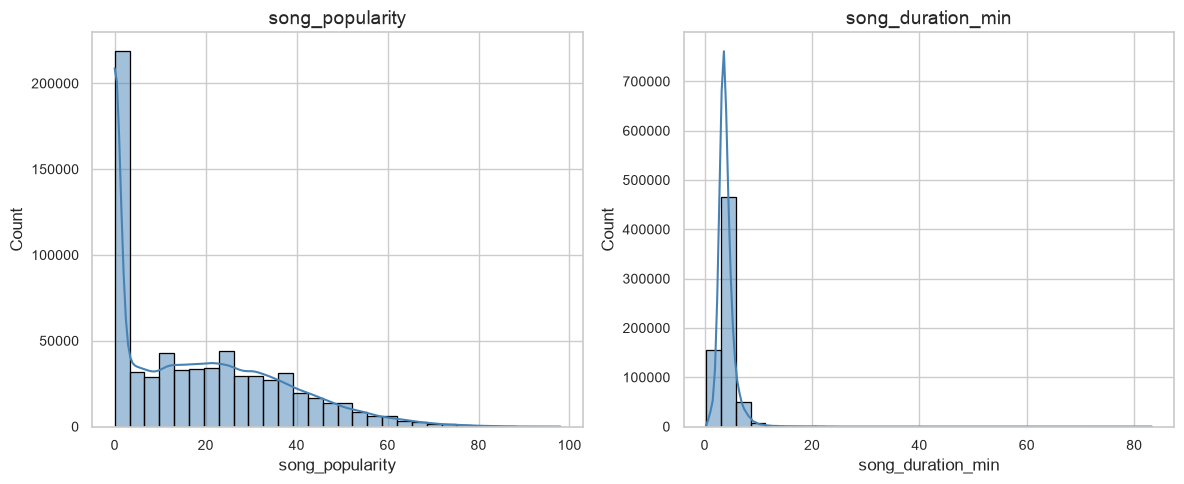

In [6]:
variables = [
    "song_popularity",
    "song_duration_min"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(12, 5)
)

plt.show()

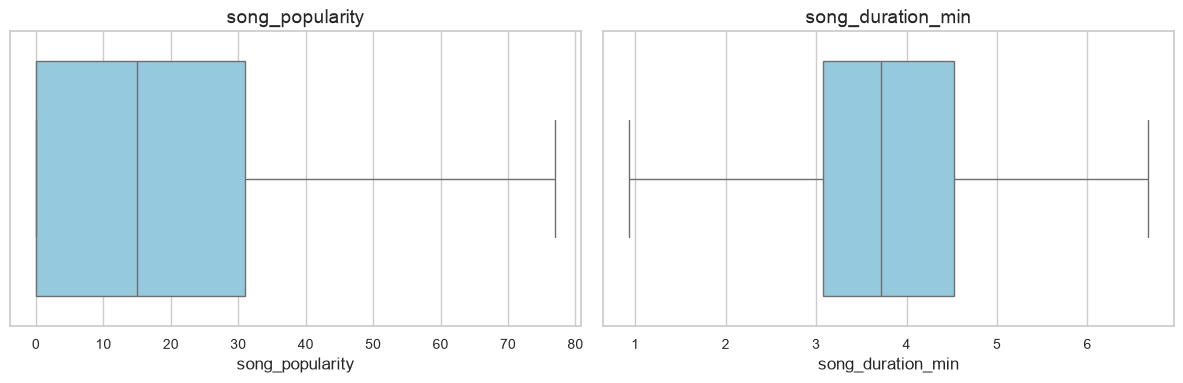

In [7]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(12, 4)
)

plt.show()

### Interpretación

La mayoría de las canciones del dataset presenta una popularidad baja, mientras que solo un pequeño número alcanza valores muy altos. En cuanto a la duración, la mayor parte de las canciones se sitúa entre los 3 y 4,5 minutos, una duración habitual en la música comercial.

Los boxplots muestran que la mayor concentración de valores se encuentra dentro de estos rangos, sin apreciarse una presencia destacable de valores atípicos.

## 5.2 ¿Cómo son los artistas del dataset?

En este apartado se analiza la distribución de la popularidad y del número de seguidores de los artistas para conocer el perfil general de los artistas incluidos en el conjunto de datos.

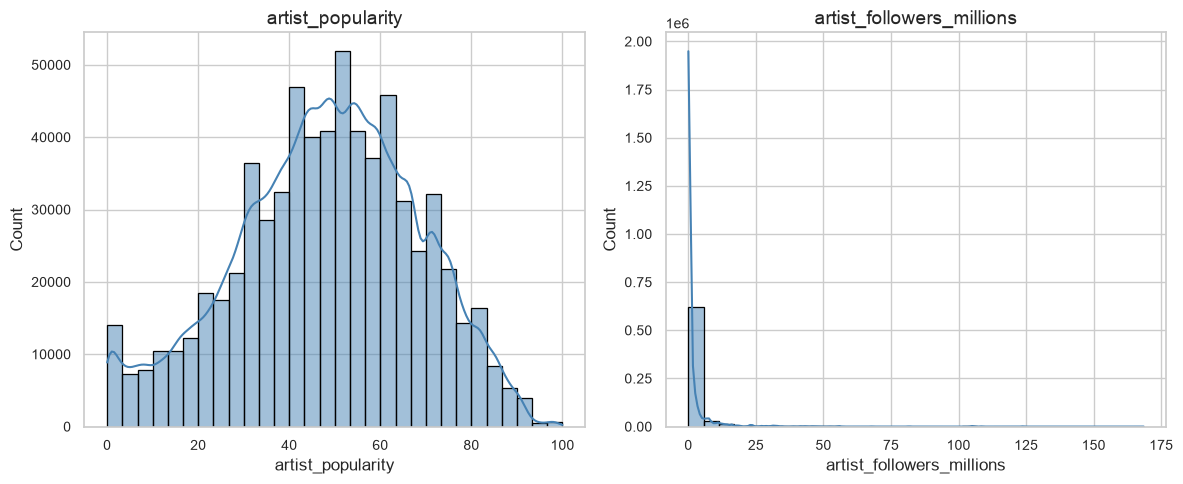

In [8]:
variables = [
    "artist_popularity",
    "artist_followers_millions"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(12, 5)
)

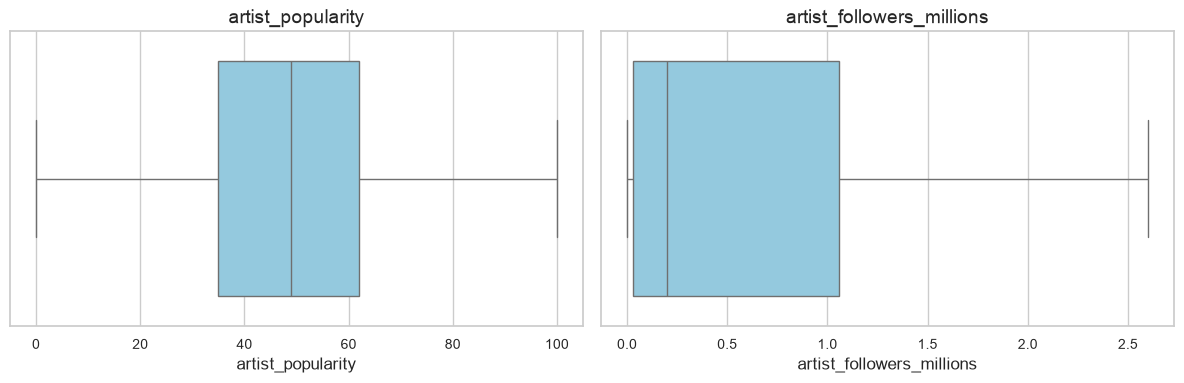

In [9]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(12, 4)
)

### Interpretación

La mayoría de los artistas del dataset presenta una popularidad media, mientras que los valores extremos son menos habituales. Respecto al número de seguidores, predominan los artistas con audiencias reducidas y solo unos pocos concentran millones de seguidores.

Los boxplots reflejan esta distribución, mostrando que la mayor parte de los artistas se concentra en un rango relativamente reducido de popularidad y seguidores.

## 5.3 ¿Cómo son las características musicales de las canciones?

En este apartado se analizan algunas de las principales características musicales proporcionadas por Spotify para conocer el perfil general de las canciones del conjunto de datos.

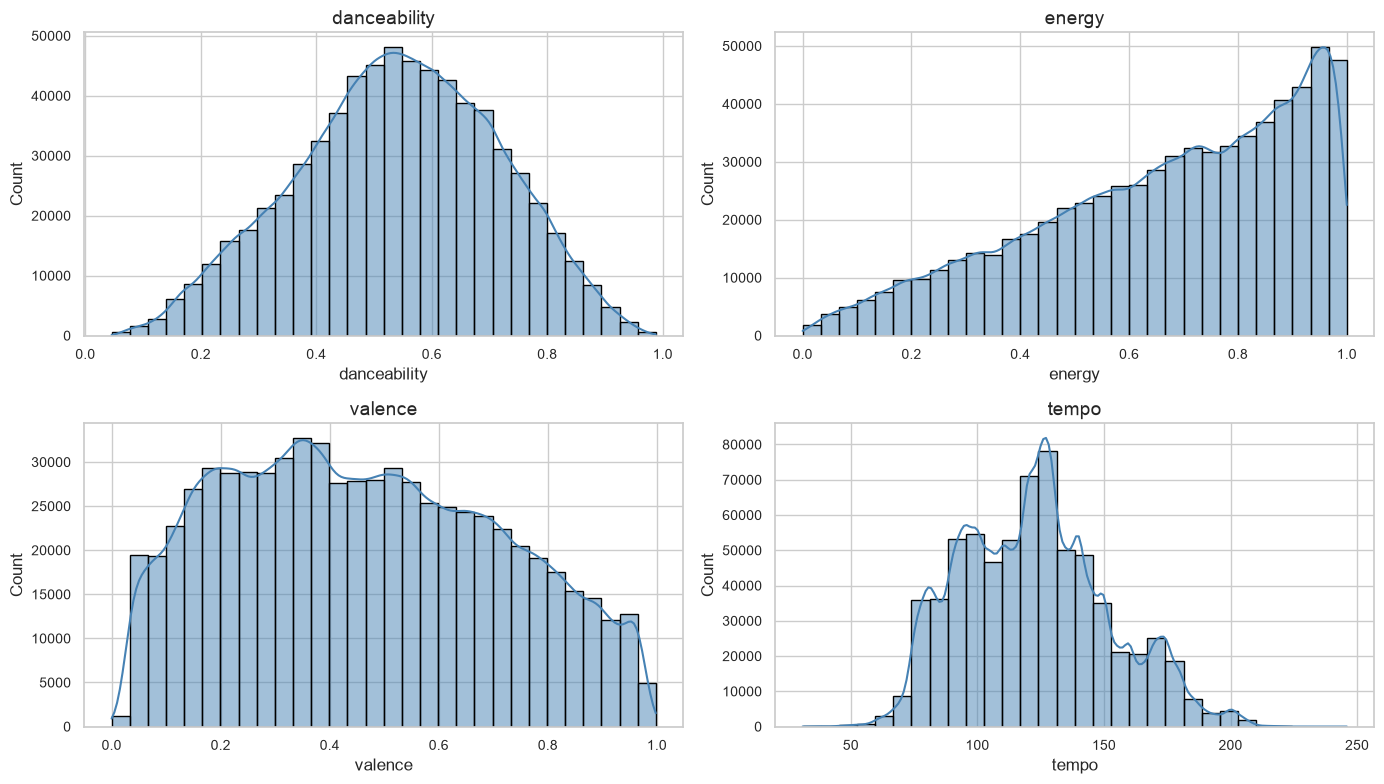

In [10]:
variables = [
    "danceability",
    "energy",
    "valence",
    "tempo"
]

sv.histograms_grid(
    df,
    columns=variables,
    kde=True,
    figsize=(14,8)
)

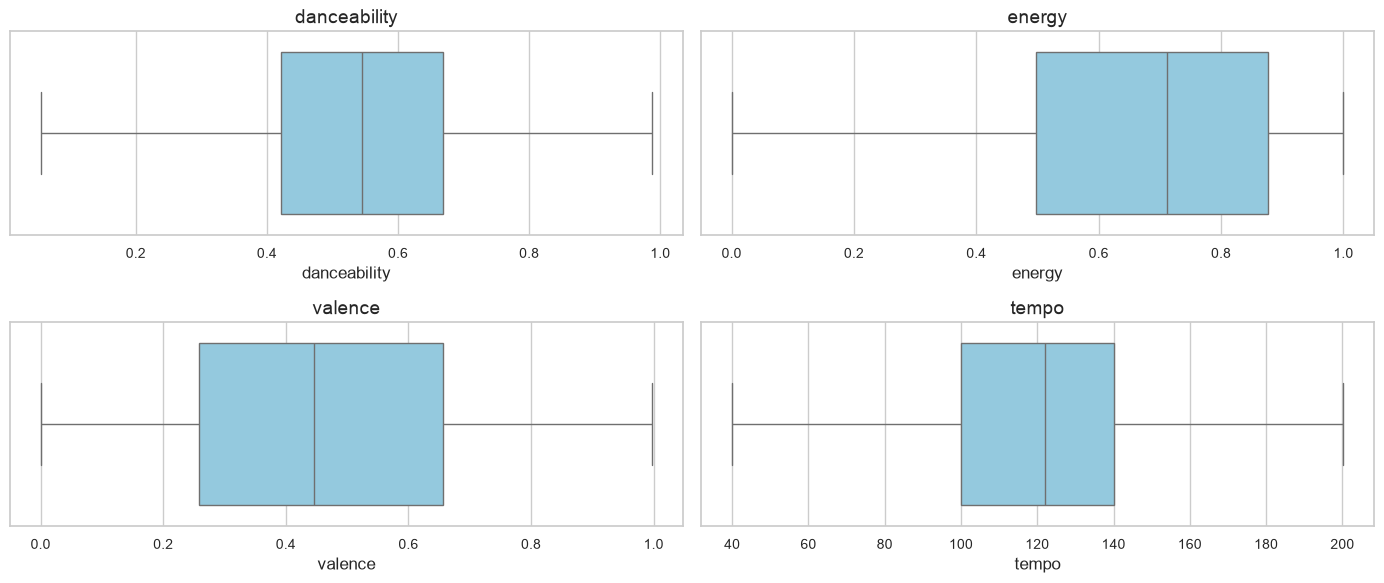

In [11]:
sv.boxplots_grid(
    df,
    columns=variables,
    figsize=(14,6)
)

### Interpretación

Las canciones del dataset presentan, en general, niveles medios de bailabilidad y valores elevados de energía, lo que indica un predominio de canciones dinámicas. La variable *valence* muestra una distribución más equilibrada, reflejando una mezcla de canciones con diferentes estados de ánimo.

Por su parte, el tempo se concentra principalmente entre los 100 y 140 BPM, con un pico alrededor de los 120 BPM, uno de los ritmos más habituales en la música actual. Los boxplots muestran una distribución bastante estable en todas las variables, sin una presencia significativa de valores atípicos.

# 6. ANÁLISIS BIVARIANTE

## 6.1 ¿Existe relación entre la popularidad del artista y la de sus canciones?

Una de las primeras preguntas que podemos plantearnos es si los artistas más populares tienden a publicar canciones más populares. Para ello se analiza la relación entre la popularidad del artista y la popularidad de sus canciones mediante un gráfico de dispersión con línea de tendencia.

In [12]:
sv.correlation_value(
    df,
    x="artist_popularity",
    y="song_popularity"
)

Pearson correlation: 0.370


np.float64(0.3698069825674101)

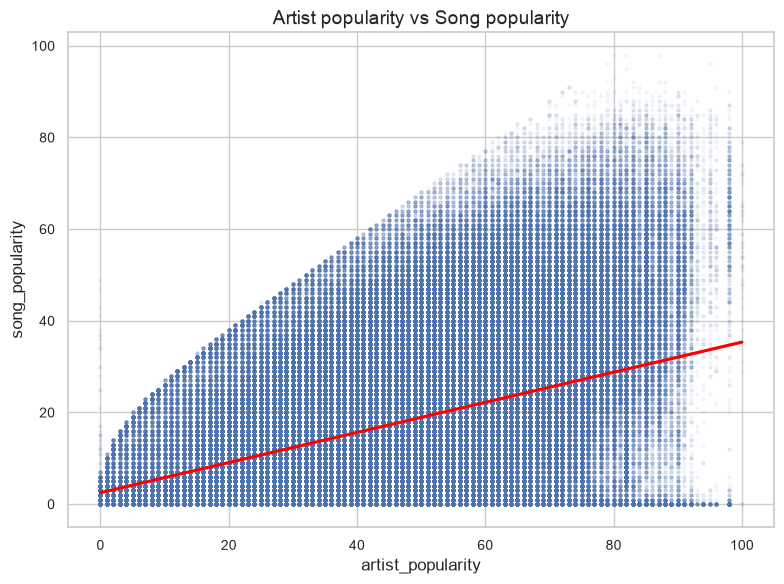

In [13]:
sv.regplot(
    df=df,
    x="artist_popularity",
    y="song_popularity",
    figsize=(8,6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Artist popularity vs Song popularity"
)

### Interpretación

Se observa una relación positiva moderada entre la popularidad del artista y la popularidad de sus canciones (r = 0.370). En general, los artistas más populares tienden a tener canciones más populares, aunque la relación no es especialmente fuerte.

La dispersión de los puntos indica que la popularidad de una canción depende también de otros factores, por lo que un artista muy conocido no garantiza que todas sus canciones tengan un gran éxito.

## 6.2 ¿Las canciones más bailables son también las más populares?

La bailabilidad (*danceability*) es una de las características más representativas de Spotify. En este apartado se analiza si existe alguna relación entre la facilidad para bailar una canción y su popularidad.

In [14]:
sv.correlation_value(
    df,
    x="danceability",
    y="song_popularity"
)

Pearson correlation: 0.144


np.float64(0.14358444908167314)

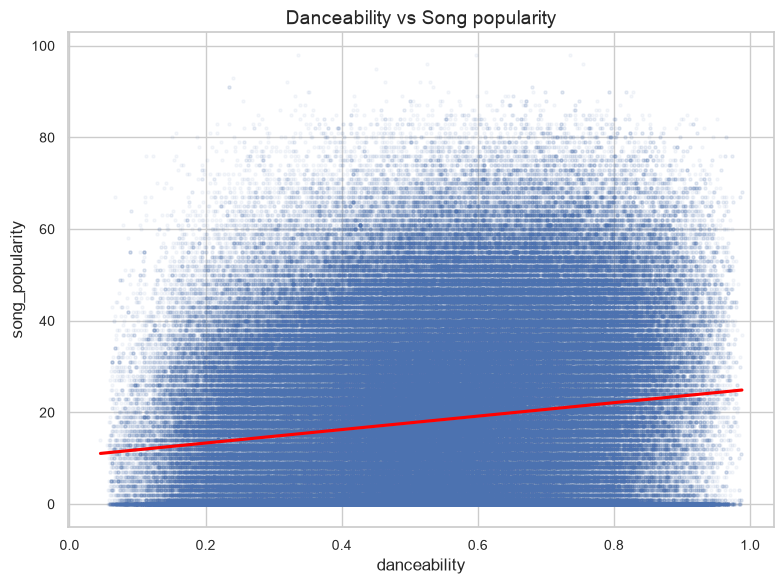

In [15]:
sv.regplot(
    df=df,
    x="danceability",
    y="song_popularity",
    figsize=(8,6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Danceability vs Song popularity"
)

### Interpretación

La relación entre la bailabilidad y la popularidad de las canciones es positiva, pero muy débil (r = 0.144). Aunque la línea de tendencia muestra un ligero incremento, la dispersión de los datos indica que la *danceability* apenas influye en la popularidad de una canción.

Esto sugiere que las canciones más bailables no son necesariamente las más populares y que el éxito depende de muchos otros factores.

## 6.3 ¿Las canciones con más energía son también las más populares?

La energía (*energy*) mide la intensidad y el dinamismo percibido de una canción. En este apartado se analiza si las canciones más enérgicas tienden a alcanzar una mayor popularidad.

In [16]:
sv.correlation_value(
    df,
    x="energy",
    y="song_popularity"
)

Pearson correlation: -0.011


np.float64(-0.011138987456151049)

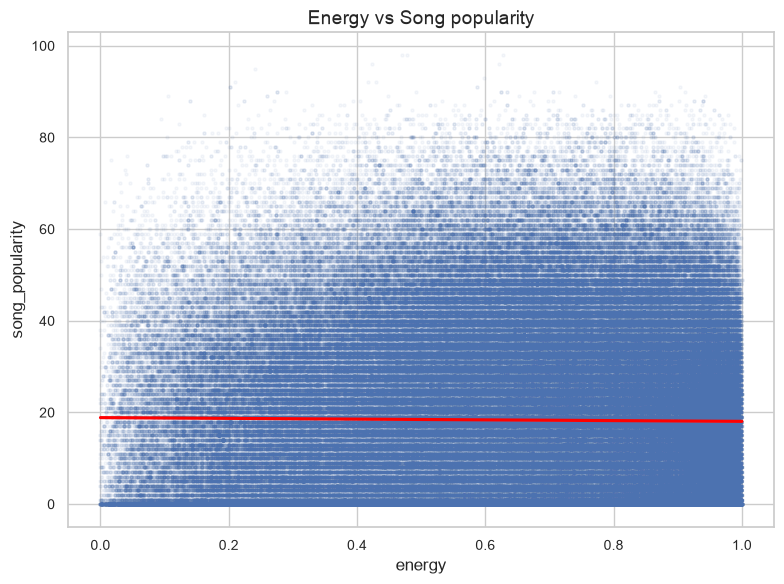

In [17]:
sv.regplot(
    df=df,
    x="energy",
    y="song_popularity",
    figsize=(8,6),
    scatter_alpha=0.05,
    scatter_size=5,
    title="Energy vs Song popularity"
)

### Interpretación

No se observa una relación lineal entre la energía de las canciones y su popularidad (r = -0.011). La línea de tendencia es prácticamente horizontal, lo que indica que el nivel de energía no parece influir en el éxito de una canción.

En este conjunto de datos es posible encontrar canciones muy populares tanto con niveles bajos como altos de energía, por lo que esta característica, por sí sola, no resulta determinante.

## 6.4 ¿Qué géneros son los más populares?

Después de analizar algunas características musicales, resulta interesante comprobar si la popularidad varía según el género principal de la canción. Para ello se compara la popularidad media de cada género presente en el conjunto de datos.

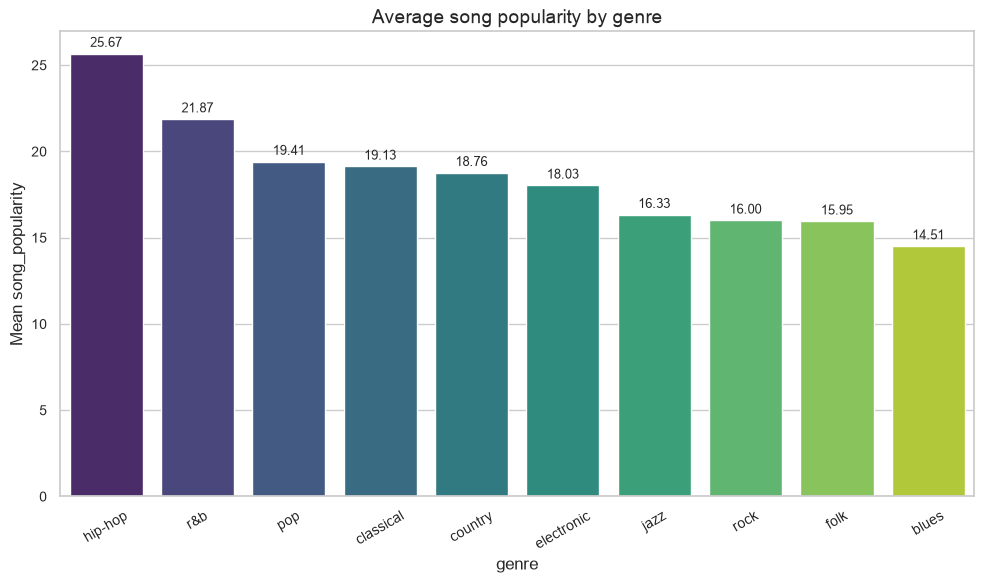

In [18]:
sv.grouped_barplot(
    df=df,
    groupby="genre",
    value="song_popularity",
    agg="mean",
    ascending=False,
    figsize=(10,6),
    rotation=30,
    palette="viridis",
    title="Average song popularity by genre"
)

### Interpretación
La popularidad media varía según el género musical. El hip-hop destaca como el género con mayor popularidad media (25,67), seguido de R&B (21,87). En cambio, géneros como blues, folk o rock presentan valores medios inferiores.

Aunque existen diferencias entre géneros, estas no son especialmente grandes, ya que la mayoría se concentra entre los 15 y 20 puntos de popularidad. Esto sugiere que el género puede influir en el éxito de una canción, pero probablemente no sea el único factor determinante.

## 6.5 ¿Ha cambiado la popularidad media de las canciones con el paso del tiempo?
La idea es comprobar si las canciones de las últimas décadas presentan, de media, una popularidad mayor o menor.

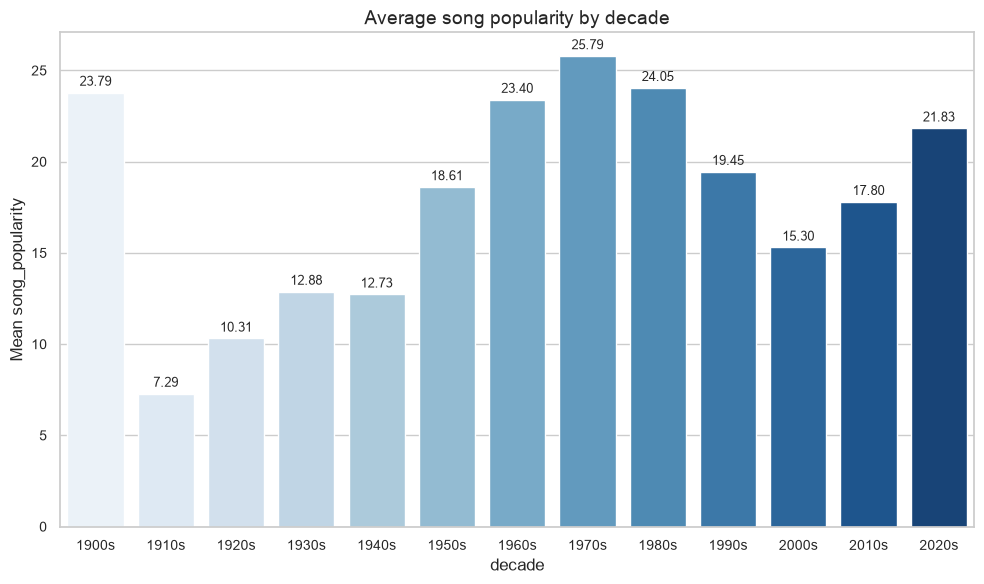

In [19]:
sv.grouped_barplot(
    df=df,
    groupby="decade",
    value="song_popularity",
    agg="mean",
    sort=False,
    rotation=0,
    palette="Blues",
    title="Average song popularity by decade"
)

### Interpretación

La popularidad media de las canciones ha variado a lo largo de las décadas. Los valores más altos se observan entre las décadas de **1960 y 1980**, alcanzando su máximo en los **años 70**.

A partir de los años 90 se aprecia un descenso de la popularidad media, especialmente en los **2000**, aunque en las décadas más recientes vuelve a observarse una ligera recuperación.

No obstante, estos resultados deben interpretarse con cautela, ya que las primeras décadas del siglo XX cuentan con un número mucho menor de canciones en el conjunto de datos, por lo que su media puede no ser representativa.

## 6.6 ¿En qué se diferencian las canciones más populares del resto?
Aquí vamos a comparar el grupo de canciones más exitosas con el resto.

La forma más sencilla es crear un grupo con el 10 % de canciones más populares y comparar algunas variables.

In [20]:
top_songs = df[
    df["song_popularity"] >= df["song_popularity"].quantile(0.90)
]

In [21]:
variables = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "song_duration_min"
]

comparison = pd.DataFrame({
    "Dataset completo": df[variables].mean(),
    "Top 10% canciones": top_songs[variables].mean()
}).round(2)

display(comparison)

,Dataset completo,Top 10% canciones
danceability,0.54,0.60
energy,0.67,0.65
valence,0.46,0.49
tempo,122.50,121.59
song_duration_min,3.97,3.81


### Interpretación

En comparación con el conjunto del dataset, las canciones más populares presentan una **mayor bailabilidad** (0,60 frente a 0,54) y un **valence ligeramente superior**, lo que indica que tienden a transmitir emociones más positivas.

Por el contrario, apenas se observan diferencias en la **energía** y el **tempo**, cuyos valores medios son muy similares en ambos grupos. Además, las canciones más populares son, de media, **ligeramente más cortas** (3,81 minutos frente a 3,97).

En conjunto, estos resultados sugieren que la **bailabilidad** es la característica que más diferencia a las canciones más exitosas, mientras que variables como la energía o el tempo parecen tener una influencia mucho menor.

## 6.7 ¿Cómo se relacionan entre sí las principales variables numéricas?

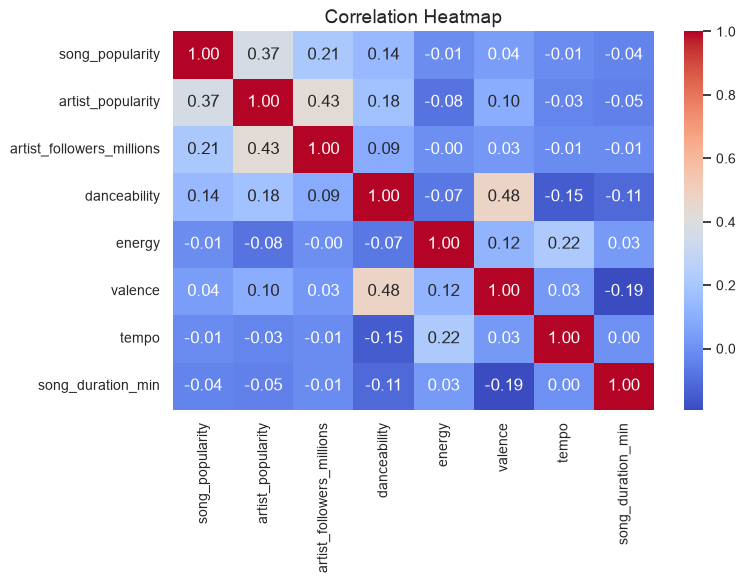

<Axes: title={'center': 'Correlation Heatmap'}>

In [22]:
variables_corr = [
    "song_popularity",
    "artist_popularity",
    "artist_followers_millions",
    "danceability",
    "energy",
    "valence",
    "tempo",
    "song_duration_min"
]

sv.correlation_heatmap(
    df,
    columns=variables_corr,
    figsize=(8,6),
    cmap="coolwarm",
    annot=True
)

Interpretación

La popularidad de las canciones se relaciona principalmente con la popularidad del artista (0,37) y, en menor medida, con sus seguidores (0,21). Las características musicales presentan relaciones muy débiles con la popularidad, destacando ligeramente la bailabilidad (0,14).

En conjunto, los resultados sugieren que el éxito de una canción está más relacionado con la popularidad del artista que con sus características musicales.

# 7. Conclusiones del EDA

El análisis exploratorio muestra que la mayoría de las canciones del dataset tienen una duración habitual de entre 3 y 4,5 minutos y niveles medios de bailabilidad y energía. La popularidad, sin embargo, está concentrada principalmente en valores bajos, con un grupo reducido de canciones muy populares.

Los resultados indican que la popularidad de una canción está más relacionada con la **popularidad del artista** que con sus características musicales. La popularidad media del artista presenta la mayor correlación (0,39), seguida de la popularidad del artista (0,37) y sus seguidores (0,23).

Entre las características musicales, la **bailabilidad** es la que presenta una mayor relación con la popularidad (0,14). Además, las canciones más populares son más bailables (0,60 frente a 0,54), mientras que variables como energía, tempo y duración presentan diferencias mínimas.

También se observan diferencias de popularidad entre géneros y décadas, aunque estos resultados deben interpretarse teniendo en cuenta la distribución de las canciones del dataset.

En conjunto, el EDA sugiere que el éxito de una canción parece estar más relacionado con la trayectoria y popularidad del artista que con unas características musicales concretas.